## Imports




#### Dependencies

Calculation: numpy, NPEET (entropy estimator tool, contained in the repo), sklearn PCA (technically this can be done with only numpy but here scikit-learn is used for convenience), standardscaler

Data visualisation: matplotlib

In [5]:
#set-ups
import numpy as np
import matplotlib.pyplot as plt
from npeet import entropy_estimators as ee
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
#test use

x = np.array([[1.3], [3.7], [5.1], [2.4], [3.4]])
y = np.array([[1.5], [3.32], [5.3], [2.3], [3.3]])

print(ee.mi(x,y))

X = np.column_stack([x, y])
pca = PCA()
pca.fit(X)

print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print("ready to run")

0.16831442143704642
[[ 0.70775233  0.70646065]
 [-0.70646065  0.70775233]]
[4.03694334 0.02973666]
[0.99268773 0.00731227]
ready to run


### Background Notes

#### PCA: Principle Component Analysis

Analysis tool used to determine principle component, in other words identify the directions along which the data varies the most.

PC1 is defined as the direction of max variance which contains most information. PC2 is orthogonal to PC1, capturing remaining variance.

##### Theoretical

Given a centered data matrix

$$
X \in \mathbb{R}^{n \times p}
$$

the covariance matrix is

$$
C = \frac{1}{n-1}X^TX
$$

PCA computes the eigenvalue decomposition (very similar to SVD)

$$
C = V\Lambda V^T
$$

where:

- $V$: eigenvectors (principal directions)
- $\Lambda$: eigenvalues (variance explained by each direction)

The principal components are ordered according to decreasing eigenvalues.

##### Application Use

*For use, refer to https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html for more details*


#### EE: Entropy Estimator

##### Theoretical


##### Application Use

*For use, refer to https://github.com/gregversteeg/NPEET for more details*

In [7]:
#helper functions
def show_2d(x,y): #visualisation
    plt.figure(figsize=(3, 3))
    plt.scatter(x, y)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal') 
    plt.show()
    
def show_3d(a,b,y): #visualisation
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(a, b, y, s=5)
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('y')
    ax.view_init(elev=30, azim=45)

    plt.show()
    
def pca_2d(a,b,y): #data
    print("PCA:")
    pca.fit(np.column_stack([y, a]))
    print(pca.components_)
    print("Variance ratio (y,a): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([y, b]))
    print(pca.components_)
    print("Variance ratio (y,b): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([a, b, y]))
    print(pca.components_)
    print("Variance ratio (a,b,y): " + str(pca.explained_variance_ratio_))
    print("--------------------------")
    
def ee_2d(a,b,y): #data
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("--------------------------")

## Linear Combination

In this section, some linear combinations (manually constructed) of parameters will be tested through both entropy test and PCA, and comparing their results. 

### 2D experiment

Run corresponding cells to get different parameter pairs and combinations:

In [8]:
#run this first and get randomly generated a & b
a = np.random.randn(1000)
b = np.random.randn(1000)

In [9]:
y = a

In [10]:
y = a + b

In [130]:
y = 2*a + 0.5*b

In [93]:
y = 3*a - 12*b

In [132]:
y = 3*a + 0.0001*b

EE:
I(y;a): 0.48386347061993346
I(y;b): 0.46030164080215363
I(a;y|b): 3.449273877975175
I(b;y|a): 3.414417488255097
--------------------------
PCA:
[[ 0.84690384  0.53174607]
 [-0.53174607  0.84690384]]
Variance ratio (y,a): [0.86755375 0.13244625]
[[ 0.84843948  0.5292924 ]
 [-0.5292924   0.84843948]]
Variance ratio (y,b): [0.86680183 0.13319817]
[[ 0.41053264  0.40595967  0.81649231]
 [-0.70578298  0.70842319  0.0026402 ]
 [ 0.57735027  0.57735027 -0.57735027]]
Variance ratio (a,b,y): [0.73962977 0.26037023 0.        ]
--------------------------


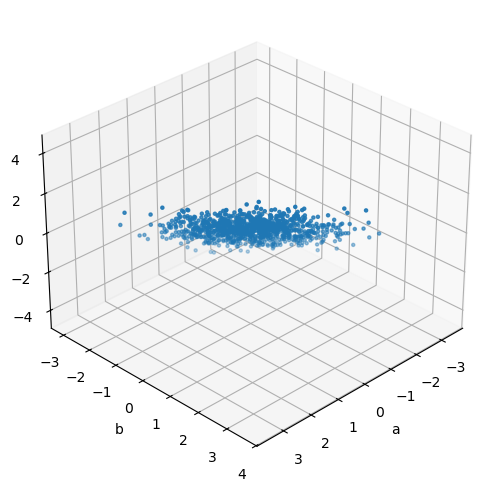

In [11]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

#### Interpretation



### 3D & Higher Dimensions

In [12]:
#helper functions
def ee_3d(a,b,c,y):
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(y;c): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("I(c;y|b): " + str(ee.cmi(c,y,b)))
    print("I(c;y|a): " + str(ee.cmi(c,y,a)))
    print("I(a;y|c): " + str(ee.cmi(a,y,c)))
    print("I(b;y|c): " + str(ee.cmi(b,y,c)))
    print("--------------------------")
    
def pca_3d(a,b,c,y): #pca result becomes hard to interpret so normalisation is used here
    print("PCA:")
    pca.fit(StandardScaler().fit_transform(np.column_stack([a, b, c, y])))
    print(pca.components_)
    print("Variance ratio: " + str(pca.explained_variance_ratio_))
    print("--------------------------")
    
def generate_linear_problem(
        n,
        sample_size=1000,
        coeff_range=(-20,20),
        seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.randn(sample_size, n)
    coeffs = np.random.randint(
        coeff_range[0],
        coeff_range[1] + 1,
        size=n
    )
    while np.all(coeffs == 0):
        coeffs = np.random.randint(
            coeff_range[0],
            coeff_range[1] + 1,
            size=n
        )
    y = X @ coeffs
    return X, y, coeffs

def pca_nd(X, y):
    data = np.column_stack([X, y])
    data = StandardScaler().fit_transform(data)
    pca = PCA()
    pca.fit(data)
    print("PCA:")
    print(pca.components_)
    print("Variance ratio:")
    print(pca.explained_variance_ratio_)

def ee_nd(X, y):
    n = X.shape[1]
    print("EE:")
    for i in range(n):
        print(
            f"I(y;x{i+1}): "
            + str(ee.mi(y, X[:,i]))
        )
    print("--------------------------")

In [13]:
c = np.random.randn(1000)

y = a + 13*b - 4*c

In [14]:
y = -3*b + 2*c

In [15]:
#results 3D
ee_3d(a,b,c,y)
pca_3d(a,b,c,y)

EE:
I(y;a): 0.04464799708311119
I(y;b): 0.933507852917857
I(y;c): 0.933507852917857
I(a;y|b): 0.04905284888866069
I(b;y|a): 0.9755294869721088
I(c;y|b): 2.613552987582973
I(c;y|a): 0.30447389624637605
I(a;y|c): 0.056481978133213866
I(b;y|c): 3.4468121177718354
--------------------------
PCA:
[[ 3.19310185e-02 -5.92280659e-01  3.98202786e-01  6.99727499e-01]
 [ 9.51130288e-01 -1.49114923e-01 -2.69925090e-01 -1.60112627e-02]
 [ 3.07134474e-01  5.23353313e-01  7.94501851e-01 -2.31631919e-02]
 [ 1.41747901e-17  5.94196661e-01 -3.70596540e-01  7.13854700e-01]]
Variance ratio: [5.10208371e-01 2.50860979e-01 2.38930650e-01 1.38639100e-17]
--------------------------


## Non-Linear Combination

Some non-linear combinations will be tested.



In [16]:
y = a**2

EE:
I(y;a): 6.1851280776890665
I(y;b): -0.015946207958034378
I(a;y|b): 2.565662112605331
I(b;y|a): -0.05639456654791743
--------------------------
PCA:
[[ 0.99089977 -0.13460181]
 [ 0.13460181  0.99089977]]
Variance ratio (y,a): [0.68836015 0.31163985]
[[ 0.99976769  0.02155389]
 [-0.02155389  0.99976769]]
Variance ratio (y,b): [0.68323552 0.31676448]
[[-0.13503921  0.02410178  0.99054708]
 [-0.59232673  0.79944262 -0.10020253]
 [ 0.79430061  0.60025878  0.09367997]]
Variance ratio (a,b,y): [0.52314511 0.24437595 0.23247894]
--------------------------


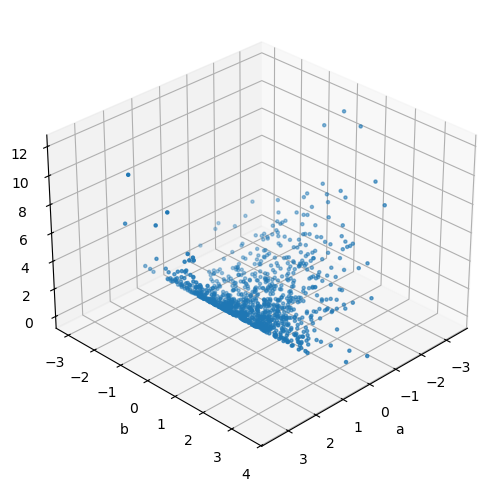

In [17]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

In [ ]:
#As dimension increases it seems like ee's possible cmi combinations increases dramatically. Do we actually calculate all these
#What's next step after the correlation is found? MI & CMI only provides information about what parameters are correlated